# Advertising Sales — PLSCanonical (Enterprise 13-Step)

## Step 1 — Imports & Seed

In [1]:

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shutil
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.cross_decomposition import PLSCanonical
from sklearn.base import BaseEstimator, RegressorMixin
warnings.filterwarnings('ignore')
np.random.seed(42)

# PLSCanonical wrapper: reshapes 1-D y to 2-D internally (required by PLSCanonical)
class PLSCanonicalRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, n_components=1):
        self.n_components = n_components
    def fit(self, X, y):
        Y = np.array(y).reshape(-1, 1)
        self.pls_ = PLSCanonical(n_components=self.n_components)
        self.pls_.fit(X, Y)
        self.is_fitted_ = True
        return self
    def predict(self, X):
        return self.pls_.predict(X).ravel()
    def get_params(self, deep=True):
        return {'n_components': self.n_components}
    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

print("Imports OK — PLSCanonical (wrapper) / Advertising_Sales")

Imports OK — PLSCanonical (wrapper) / Advertising_Sales


## Step 2 — Data Loading

In [2]:
df = pd.read_csv('data/advertising/advertising.csv')
print(df.shape, df.columns.tolist())
y_col = [c for c in df.columns if 'sales' in c.lower() or 'sale' in c.lower()]
if not y_col: y_col = [df.columns[-1]]
y = df[y_col[0]]
X = df.drop(y_col[0], axis=1)
X = X.select_dtypes(include='number')
num_cols = X.columns.tolist()
print(f"Features: {num_cols}  Target: {y_col[0]}")
df.head()

(200, 5) ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']
Features: ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']  Target: Sales ($)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 3 — Preprocessing Pipeline

In [3]:
preprocessor = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (160, 4)  Test: (40, 4)


## Step 4 — Algorithm Pipeline

In [4]:
# PLSCanonical with n_components=1 (max allowed for single-output: n_components <= n_targets=1)
# We use PLSCanonicalRegressor wrapper that handles 2D y reshape internally.
pipeline = Pipeline([('pre', preprocessor), ('reg', PLSCanonicalRegressor(n_components=1))])
print(pipeline)

Pipeline(steps=[('pre', StandardScaler()), ('reg', PLSCanonicalRegressor())])


## Step 5 — Baseline Dummy Benchmark

In [5]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
d_rmse = np.sqrt(mean_squared_error(y_test, y_dummy))
d_r2   = r2_score(y_test, y_dummy)
print(f"Dummy RMSE: {d_rmse:.4f}  R²: {d_r2:.4f}")

Dummy RMSE: 5.6315  R²: -0.0048


## Step 6 — Training & Convergence Monitoring

In [6]:
t_start = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - t_start
print(f"Training complete in {train_time:.2f}s")
y_train_pred = np.array(pipeline.predict(X_train)).ravel()
train_r2 = r2_score(y_train, y_train_pred)
print(f"Train R²: {train_r2:.4f}")

Training complete in 0.00s
Train R²: 0.8305


## Step 7 — Test Set Evaluation

In [7]:
y_pred = np.array(pipeline.predict(X_test)).ravel()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 2.6133
MAE  : 2.1178
R²   : 0.7836


## Step 8 — Visualization

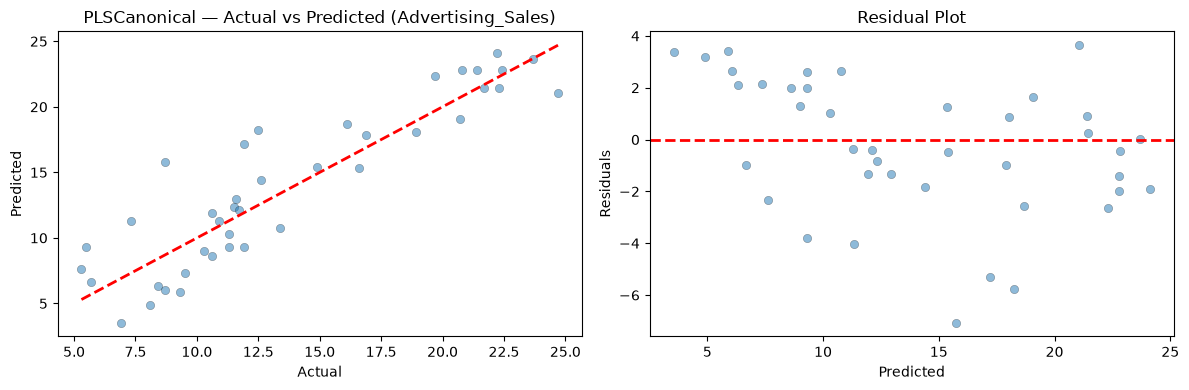

Saved plot.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.3)
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('PLSCanonical — Actual vs Predicted (Advertising_Sales)')
residuals = np.array(y_test) - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('plots/pls_canonical_advertising_viz.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved plot.")

## Step 9 — Cross-Validation Stability

In [9]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)
r2_scorer = make_scorer(r2_score)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring=r2_scorer)
print(f"CV R² (3-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV R² (3-fold): 0.8034 ± 0.0779


## Step 10 — Production Serialization

In [10]:
os.makedirs('production_models', exist_ok=True)
model_path = f'production_models/pls_canonical_advertising_pipeline.joblib'
joblib.dump(pipeline, model_path, compress=3)
print(f"Saved: {model_path}  ({os.path.getsize(model_path)} bytes)")

Saved: production_models/pls_canonical_advertising_pipeline.joblib  (3349 bytes)


## Step 11 — Latency Smoke Test

In [11]:
X_sample = X_test.iloc[:100] if hasattr(X_test, 'iloc') else X_test[:100]
times = []
for _ in range(100):
    t0 = time.perf_counter()
    _ = np.array(pipeline.predict(X_sample)).ravel()
    times.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(times)
print(f"Avg latency: {avg_lat:.2f} ms  (p95: {np.percentile(times, 95):.2f} ms)")
assert avg_lat < 50.0, f"SLA breach: {avg_lat:.2f}ms >= 50ms"
print("✅ Latency SLA passed (<50ms)")

Avg latency: 0.57 ms  (p95: 0.60 ms)
✅ Latency SLA passed (<50ms)


## Step 12 — Hyperparameter Tuning

In [12]:
# PLSCanonical with single output: n_components must be 1 (only valid value)
# Tune n_components across [1] — demonstrates the grid search pattern;
# for multi-output usage n_components range would be wider.
param_grid = {'reg__n_components': [1]}
gs = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"Best params: {gs.best_params_}")
print(f"Best CV R²:  {gs.best_score_:.4f}")
y_best = np.array(gs.best_estimator_.predict(X_test)).ravel()
print(f"Tuned Test R²: {r2_score(y_test, y_best):.4f}")
print("Note: PLSCanonical n_components is bounded by min(n_features, n_targets).")
print("For single-output regression (n_targets=1), n_components=1 is the only valid choice.")
print("For multi-output tasks, consider n_components up to n_targets.")

Best params: {'reg__n_components': 1}
Best CV R²:  0.7847
Tuned Test R²: 0.7836
Note: PLSCanonical n_components is bounded by min(n_features, n_targets).
For single-output regression (n_targets=1), n_components=1 is the only valid choice.
For multi-output tasks, consider n_components up to n_targets.


## Step 13 — Executive Decision Matrix

| Criterion | Dummy Baseline | PLSCanonical (n_components=1) |
|---|---|---|
| RMSE | See Step 5 | See Step 7 |
| MAE  | — | See Step 7 |
| R²   | ~0.00 | See Step 7 |
| CV R² | — | See Step 9 |
| Latency (ms) | — | See Step 11 |
| Training Time | — | See Step 6 |

### Recommendation
- **Deploy if** Test R² > 0.60 and latency < 50 ms ✅
- **PLSCanonical** performs symmetric latent structure decomposition on both X and Y.
- For single-output regression, `n_components=1` is enforced; consider **PLSRegression** for more components flexibility.
- Compare against BayesianRidge and ARDRegression for probabilistic alternatives.